In [1]:
import time
from typing import List
import itertools
import numpy as np
from tqdm.auto import tqdm
from scipy.integrate import odeint, solve_ivp
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
import torchode

from ftnode.node import (FeluSigmoidMLP, GeluSigmoidMLP, FTNODE)

import torch
import torch.nn as nn
device='cpu'

from ftnode.utils import set_global_seed

seed = 1234
set_global_seed(seed = seed)
random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [2]:
def genetic_toggle_switch(state,t, alpha1, alpha2, beta, gamma):
    """
    Computes derivatives for Equation 27 (Li & Lin, 2013).
    """
    x1, x2 = state
    # Note: In this symmetric simulation, alpha1=alpha2 and beta=gamma
    dx1dt = -x1 + alpha1 / (1 + x2**beta)
    dx2dt = -x2 + alpha2 / (1 + x1**gamma)
    return [dx1dt, dx2dt]

In [3]:
t_max = 100
n_colloc = 501

t = np.linspace(0,t_max,n_colloc)

x1s = np.linspace(0,6,9)
x2s = np.linspace(0,6,9)

alphas1 = np.linspace(0,5,5)
alphas2 = np.linspace(0,5,5)
alphas1[0]=0.1
alphas2[0]=0.1

betas = np.linspace(0,5,5)
betas[0] = 0.1

gammas = np.linspace(0,5,5)
gammas[0] = 0.1

total_iter = len(alphas1)*len(alphas2)*len(betas)*len(gammas)

Us = []
Xs = []
for args in tqdm(itertools.product(alphas1,alphas2, betas,gammas),total=total_iter,):
    alpha1,alpha2, beta, gamma = args

    for x0 in itertools.product(x1s,x2s):
        sol = odeint(genetic_toggle_switch, x0, t, args=(alpha1,alpha2,beta,gamma))
        Xs.append(sol)
        Us.append(args)

Us = np.array(Us)
Xs = np.array(Xs)

len(Xs)


  0%|          | 0/625 [00:00<?, ?it/s]

50625

In [4]:
dXs = np.zeros_like(Xs)
T = t[np.newaxis,:,np.newaxis]
X_diff = Xs[:,2:,:] - Xs[:,:-2,:]
T_diff = T[:,2:,:] - T[:,:-2,:]

dXs[:,1:-1,:] = X_diff/T_diff
dXs[:,0,:] = (Xs[:,1,:] - Xs[:,0,:]) / (T[:,1,:] - T[:,0,:])
dXs[:,-1,:] = (Xs[:,-1,:] - Xs[:,-2,:]) / (T[:,-1,:] - T[:,-2,:])

In [5]:
# eps_tol = 5e-3
eps_tol = 1e-3
transient_idx = np.argmax(np.all(np.cumsum(np.abs(dXs)[:,::-1,:] >= eps_tol,axis=1)[:,::-1,:]==0,axis=2),axis=1)

In [6]:
dX_tensor = [
    torch.tensor(dxi,dtype=torch.float32,device=device) for dxi in dXs
]
X_tensor = [
    torch.tensor(xi,dtype=torch.float32,device=device) for xi in Xs
]
U_tensor = [
    torch.tensor(ui,dtype=torch.float32,device=device) for ui in Us
]

T_tensor = [
    torch.tensor(t,dtype=torch.float32, device=device) for _ in range(len(Xs))
]

In [7]:
class GradDataset(torch.utils.data.Dataset):
    def __init__(self, dX: List, X: List, T: List, U: List, Transient_idx: List):
        self.dX = dX
        self.X = X
        self.T = T
        self.U = U
        self.trans_idx = Transient_idx

    def __len__(self):
        return len(self.dX)

    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(
                f"Index {idx} is out of bounds of dataset size: {len(self)}."
            )

        dXi = self.dX[idx]
        Xi = self.X[idx]
        ti = self.T[idx]
        ui = self.U[idx]
        trans_idx = self.trans_idx[idx]

        return dXi, Xi, ti, ui, trans_idx

dataset = GradDataset(dX = dX_tensor,X = X_tensor, T = T_tensor, U = U_tensor, Transient_idx=transient_idx)

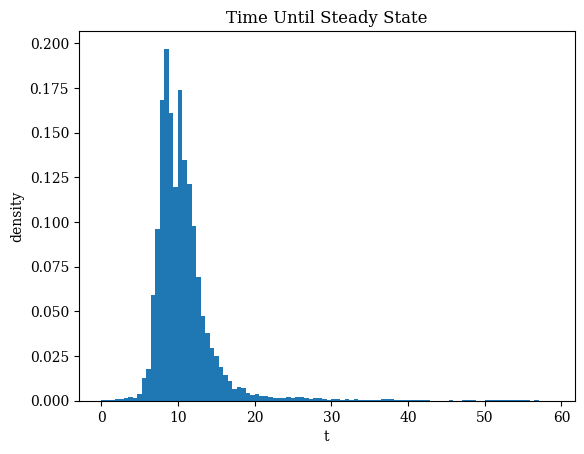

In [8]:
plt.title("Time Until Steady State")
plt.hist(t[transient_idx],bins=100,density =True)
plt.xlabel("t")
plt.ylabel("density")
plt.show()

# Run $k$-Folds Cross Validation

In [9]:
k_folds = 10

In [10]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, SubsetRandomSampler
import time
import copy

In [11]:
avg_best_val_losses = []
avg_best_train_losses = []

In [12]:
# --- Configuration ---
k_folds = k_folds
n_epochs = 500  
batch_size = 200 
learning_rate = 1e-2
print_every = 10
_precision = 6
random_state = random_state
solve_method = 'tsit5'


kfold = KFold(n_splits=k_folds, shuffle=True, random_state=random_state)

val_results = []
train_results = []

def get_fresh_model_components():
    f = FeluSigmoidMLP(
        dims = [2,20,20,20,2],
        lower_bound = -10,
        upper_bound =-0.1
    )

    g = GeluSigmoidMLP(
        dims = [6,20,20,20,2],
        lower_bound = -1,
        upper_bound = 8
    )

    model = FTNODE(f,g)

    return f, g, model 

# ==========================================
# K-Fold Loop
# ==========================================
for fold, (train_ids, val_ids) in enumerate(kfold.split(dataset)):
    print(f'\n--- FOLD {fold+1}/{k_folds} ---')

    fold_seed = random_state + fold
    set_global_seed(fold_seed)

    # 1. Re-initialize Model & Optimizer for this fold
    f_fold, g_fold, model_fold = get_fresh_model_components()
    model_fold.train() 
    
    loss_criteria = nn.MSELoss()
    

    opt = torch.optim.Adam(
        list(f_fold.parameters()) + list(g_fold.parameters()), 
        lr=learning_rate
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=10
    )

    # 2. Create DataLoaders for this fold
    train_subsampler = SubsetRandomSampler(train_ids)
    val_subsampler = SubsetRandomSampler(val_ids)

    trainloader = DataLoader(dataset, batch_size=batch_size, sampler=train_subsampler)
    valloader = DataLoader(dataset, batch_size=batch_size, sampler=val_subsampler)

    # 3. Training & Validation Loop
    best_val_loss = float('inf')
    fold_losses = []

    for epoch in tqdm(range(n_epochs), desc=f"Fold {fold+1}"):
        t1 = time.time()
        
        # --- TRAINING ---
        model_fold.train()
        train_loss = 0.0
        
        for batch_idx, (dXi, Xi, ti, ui,trans_indices) in enumerate(trainloader):
            x0i = Xi[:, 0, :]
            
            ui_expanded = ui.unsqueeze(dim=1).expand((-1,len(ti.T),-1))
            u_func = lambda t: ui_expanded


            opt.zero_grad()

            dXi_pred = model_fold(ti,Xi,u_func)

            batch,n_time,dim = dXi.shape
            mask = torch.arange(n_time,device=device)[None,:] < trans_indices[:,None]
            mask = mask.unsqueeze(-1)

            loss_per_elem = loss_criteria(dXi, dXi_pred)

            masked_loss = loss_per_elem*mask

            loss = masked_loss.sum() / mask.sum().clamp(min=1)



            # loss = loss_criteria(dXi, dXi_pred)
            # loss = loss_criteria(Xi, Xi_pred)
                
            loss.backward()
            opt.step()
            
            train_loss += loss.item()
        
        train_loss /= len(trainloader)

        # --- VALIDATION ---
        model_fold.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_idx, (dXi, Xi, ti, ui, trans_indices) in enumerate(valloader):
                x0i = Xi[:, 0, :]
                ui_expanded = ui.unsqueeze(dim=1).expand((-1,len(ti.T),-1))
                u_func = lambda t: ui_expanded

                dXi_pred = model_fold(ti,Xi,u_func)

                batch,n_time,dim = dXi.shape
                mask = torch.arange(n_time,device=device)[None,:] < trans_indices[:,None]
                mask = mask.unsqueeze(-1)

                loss_per_elem = loss_criteria(dXi, dXi_pred)
                masked_loss = loss_per_elem*mask

                loss = masked_loss.sum() / mask.sum().clamp(min=1)

                

                # loss = loss_criteria(dXi, dXi_pred)

                val_loss += loss.item()
        
        val_loss /= len(valloader)
        
        # --- SCHEDULER & LOGGING ---
        epoch_time = time.time() - t1
        
        scheduler.step(val_loss) 
        cur_lr = opt.param_groups[0]['lr']

        if epoch <= 5 or epoch % print_every == 0 or epoch == n_epochs - 1:
            print(
                f"Epoch {epoch}: "
                f"Train Loss = {train_loss:.{_precision}e}, "
                f"Val Loss = {val_loss:.{_precision}e}, "
                f"Time = {epoch_time:.{_precision}e}, "
                f"lr = {cur_lr:.{_precision}e}"
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_train_loss = train_loss
            best_fold = fold
            
    print(f"Fold {fold+1} Best Val Loss: {best_val_loss:.{_precision}e}")
    val_results.append(best_val_loss)
    train_results.append(best_val_train_loss)

# --- SUMMARY ---
print("\nK-Fold Cross Validation Results:")
avg_loss = np.mean(val_results)
avg_train_loss = np.mean(train_results)
print(f"Average Best Validation Loss: {avg_loss:.{_precision}e}")
avg_best_val_losses.append(avg_loss)
avg_best_train_losses.append(avg_train_loss)
avg_best_val_losses, np.argmin(avg_best_val_losses)


--- FOLD 1/10 ---
[Seed] Deterministic mode enabled (may reduce speed).


Fold 1:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 0: Train Loss = 3.678308e+00, Val Loss = 9.347146e-02, Time = 1.321096e+01, lr = 1.000000e-02
Epoch 1: Train Loss = 6.190251e-02, Val Loss = 5.292625e-02, Time = 1.283238e+01, lr = 1.000000e-02
Epoch 2: Train Loss = 5.186255e-02, Val Loss = 5.080276e-02, Time = 1.331238e+01, lr = 1.000000e-02
Epoch 3: Train Loss = 4.969489e-02, Val Loss = 4.874840e-02, Time = 1.307766e+01, lr = 1.000000e-02
Epoch 4: Train Loss = 4.799591e-02, Val Loss = 4.724530e-02, Time = 1.335495e+01, lr = 1.000000e-02
Epoch 5: Train Loss = 4.684553e-02, Val Loss = 4.628387e-02, Time = 1.224441e+01, lr = 1.000000e-02
Epoch 10: Train Loss = 4.429327e-02, Val Loss = 4.406333e-02, Time = 1.319688e+01, lr = 1.000000e-02
Epoch 20: Train Loss = 4.259877e-02, Val Loss = 4.256668e-02, Time = 1.319138e+01, lr = 1.000000e-02
Epoch 30: Train Loss = 3.957730e-02, Val Loss = 3.924003e-02, Time = 1.402000e+01, lr = 1.000000e-02
Epoch 40: Train Loss = 4.517115e-02, Val Loss = 4.035958e-02, Time = 1.395649e+01, lr = 1.000000e

KeyboardInterrupt: 